# Derivazione delle causal relations

**Progetto:** Instance Graph a ordine parziale in ambito
Object-Centric Process Mining

**Autori:** Nicolò Ianni e Danilo La Palombara

## Obiettivo

Questo notebook elimina la dipendenza operativa dal JSON
contenente le sei causal relations manuali del caso
`o-990424`.

La pipeline analizzata è:

```text
OCEL Order Management
→ OC-DFG
→ valutazione delle successioni per object type
→ filtering mediante dependency e supporto relativo
→ causal relations candidate
→ process execution reale
→ Instance Graph object-centric
```

Le causal relations non vengono presentate come una lettura
diretta della OCPN. Gli esperimenti mostrano infatti che la
rete `items` scoperta da PM4Py è troppo permissiva.

## 1. Configurazione

Il caso reale analizzato è l'ordine `o-990424`.

Vengono considerati solamente i tipi strutturali:

- `orders`;
- `items`;
- `packages`.

`products` ed `employees` sono esclusi perché sono oggetti
informativi o condivisi che possono collegare processi
differenti.

In [1]:
from collections import deque
from pathlib import Path
import sys

import networkx as nx
import pandas as pd
import pm4py
from IPython.display import Image, display
from pm4py.objects.petri_net.obj import PetriNet


PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))


from ocpm_partial_order.config import (
    GRAPHS_DIR,
    MAIN_DATASET_DB,
)
from ocpm_partial_order.discovery import (
    derive_causal_relations,
    discover_ocpn,
    score_causal_relations,
)
from ocpm_partial_order.extraction import (
    extract_order_centred_execution,
)
from ocpm_partial_order.graphs.concurrency import (
    find_incomparable_event_pairs,
)
from ocpm_partial_order.graphs.instance_graph import (
    build_instance_graph,
)
from ocpm_partial_order.io.ocel_loader import (
    load_ocel2_sqlite,
)
from ocpm_partial_order.visualization.graph_visualizer import (
    save_instance_graph,
)


ORDER_ID = "o-990424"

STRUCTURAL_TYPES = {
    "orders",
    "items",
    "packages",
}

DEPENDENCY_THRESHOLD = 0.90
RELATIVE_SUPPORT_THRESHOLD = 0.05

EXPECTED_TOPOLOGY = {
    ("place order", "confirm order"),
    ("confirm order", "pay order"),
    ("place order", "pick item"),
    ("pick item", "create package"),
    ("create package", "send package"),
    ("send package", "package delivered"),
}


print("Dataset:", MAIN_DATASET_DB)
print("Ordine:", ORDER_ID)
print(
    "Object type:",
    sorted(STRUCTURAL_TYPES),
)
print(
    "Dependency threshold:",
    DEPENDENCY_THRESHOLD,
)
print(
    "Relative support threshold:",
    RELATIVE_SUPPORT_THRESHOLD,
)



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




Dataset: C:\Users\nicol\ocpm-partial-order\ocpm-partial-order\data\raw\order_management.sqlite
Ordine: o-990424
Object type: ['items', 'orders', 'packages']
Dependency threshold: 0.9
Relative support threshold: 0.05


## 2. Caricamento dell'OCEL e discovery

L'OCEL viene caricato una sola volta. Da esso ricaviamo:

- la OCPN, per studiarne la struttura;
- l'OC-DFG, per misurare le successioni effettivamente
  osservate per ogni tipo di oggetto.

In [2]:
ocel = load_ocel2_sqlite(
    MAIN_DATASET_DB
)

ocpn = discover_ocpn(ocel)
ocdfg = pm4py.discover_ocdfg(ocel)


print("Eventi:", len(ocel.events))
print("Oggetti:", len(ocel.objects))
print(
    "Relazioni:",
    len(ocel.relations),
)
print(
    "Attività OC-DFG:",
    len(ocdfg["activities"]),
)
print(
    "Tipi di oggetto:",
    sorted(ocdfg["object_types"]),
)

Eventi: 21008
Oggetti: 10825
Relazioni: 143463
Attività OC-DFG: 11
Tipi di oggetto: ['employees', 'items', 'orders', 'packages', 'products']


## 3. Primo tentativo: cammini nella OCPN

Inizialmente consideriamo una relazione tra due attività
quando dalla prima transizione visibile è possibile
raggiungere la seconda attraversando solamente places e
transizioni invisibili.

Questo tentativo funziona per `orders` e `packages`, ma
produce una forte overgeneralizzazione per `items`.

In [3]:
CASE_ACTIVITIES = {
    "place order",
    "confirm order",
    "pay order",
    "pick item",
    "create package",
    "send package",
    "package delivered",
}

EXPECTED_BY_TYPE = {
    "orders": {
        (
            "place order",
            "confirm order",
        ),
        (
            "confirm order",
            "pay order",
        ),
    },
    "items": {
        (
            "place order",
            "pick item",
        ),
        (
            "pick item",
            "create package",
        ),
    },
    "packages": {
        (
            "create package",
            "send package",
        ),
        (
            "send package",
            "package delivered",
        ),
    },
}


def next_visible_labels(
    source_transition,
):
    queue = deque(
        arc.target
        for arc in source_transition.out_arcs
    )

    visited = set()
    labels = set()

    while queue:
        node = queue.popleft()

        if node in visited:
            continue

        visited.add(node)

        if (
            isinstance(
                node,
                PetriNet.Transition,
            )
            and node.label is not None
        ):
            labels.add(node.label)
            continue

        queue.extend(
            arc.target
            for arc in node.out_arcs
        )

    return labels


def visible_successions(net):
    relations = set()

    for transition in net.transitions:
        if transition.label is None:
            continue

        for target in next_visible_labels(
            transition
        ):
            relations.add(
                (
                    transition.label,
                    target,
                )
            )

    return relations


naive_rows = []

for object_type in sorted(
    STRUCTURAL_TYPES
):
    net, _, _ = ocpn[
        "petri_nets"
    ][object_type]

    all_relations = visible_successions(
        net
    )

    relevant_relations = {
        relation
        for relation in all_relations
        if relation[0] in CASE_ACTIVITIES
        and relation[1] in CASE_ACTIVITIES
    }

    missing_relations = (
        EXPECTED_BY_TYPE[object_type]
        - relevant_relations
    )

    additional_relations = (
        relevant_relations
        - EXPECTED_BY_TYPE[object_type]
    )

    naive_rows.append(
        {
            "object_type": object_type,
            "places": len(net.places),
            "transitions": len(
                net.transitions
            ),
            "all_relations": len(
                all_relations
            ),
            "case_relations": len(
                relevant_relations
            ),
            "missing": len(
                missing_relations
            ),
            "additional": len(
                additional_relations
            ),
        }
    )


naive_table = pd.DataFrame(
    naive_rows
)

display(naive_table)

,object_type,places,transitions,all_relations,case_relations,missing,additional
0,items,5,14,110,42,0,40
1,orders,7,8,5,2,0,0
2,packages,7,8,5,2,0,0


### Risultato del primo tentativo

La rete `items` produce 42 relazioni tra le attività del
caso reale, di cui 40 aggiuntive rispetto al riferimento
manuale.

Il problema è che:

> la possibilità di eseguire `B` dopo `A` non dimostra
> automaticamente che `A` causi `B`.

La rete `items` contiene un loop che consente numerose
successioni in entrambe le direzioni. Leggere tutti i
cammini come relazioni causali distruggerebbe il
parallelismo dell'Instance Graph.

## 4. Dependency e supporto relativo

Per una successione `A → B` utilizziamo la misura:

$$
dependency(A,B)=
\frac{f(A,B)-f(B,A)}
{f(A,B)+f(B,A)+1}
$$

Aggiungiamo il supporto relativo:

$$
relative\_support(A,B)=
\frac{f(A,B)}
{\max_X f(A,X)}
$$

Una relazione viene selezionata quando supera entrambe
le soglie:

- dependency minima: `0.90`;
- supporto relativo minimo: `0.05`.

In [4]:
evidence = score_causal_relations(
    ocdfg=ocdfg,
    object_types=STRUCTURAL_TYPES,
)

causal_relations = derive_causal_relations(
    ocdfg=ocdfg,
    dependency_threshold=(
        DEPENDENCY_THRESHOLD
    ),
    relative_support_threshold=(
        RELATIVE_SUPPORT_THRESHOLD
    ),
    object_types=STRUCTURAL_TYPES,
)

execution = extract_order_centred_execution(
    ocel=ocel,
    order_id=ORDER_ID,
)

execution_activities = {
    event.activity
    for event in execution.events
}

relevant_evidence = [
    item
    for item in evidence
    if item.relation in causal_relations
    and item.relation.source_activity
    in execution_activities
    and item.relation.target_activity
    in execution_activities
]


evidence_rows = []

for item in sorted(
    relevant_evidence,
    key=lambda value: (
        value.relation.source_activity,
        value.relation.target_activity,
        value.relation.object_type,
    ),
):
    evidence_rows.append(
        {
            "source": (
                item.relation
                .source_activity
            ),
            "target": (
                item.relation
                .target_activity
            ),
            "object_type": (
                item.relation.object_type
            ),
            "forward": (
                item.forward_frequency
            ),
            "backward": (
                item.backward_frequency
            ),
            "dependency": round(
                item.dependency,
                3,
            ),
            "relative_support": round(
                item.relative_support,
                3,
            ),
        }
    )


evidence_table = pd.DataFrame(
    evidence_rows
)

print(
    "Relazioni selezionate complessive:",
    len(causal_relations),
)
print(
    "Relazioni rilevanti per "
    "l'esecuzione:",
    len(relevant_evidence),
)

display(evidence_table)

Relazioni selezionate complessive: 22
Relazioni rilevanti per l'esecuzione: 10


,source,target,object_type,forward,backward,dependency,relative_support
0,confirm order,pay order,items,632,0,0.998,0.179
1,confirm order,pay order,orders,1557,0,0.999,1.000
2,create package,send package,items,1122,0,0.999,1.000
3,create package,send package,packages,1128,0,0.999,1.000
4,pick item,create package,items,5290,66,0.975,1.000
5,place order,confirm order,items,1797,0,0.999,0.938
6,place order,confirm order,orders,2000,0,1.000,1.000
7,place order,pick item,items,1915,0,0.999,1.000
8,send package,package delivered,items,913,0,0.999,1.000
9,send package,package delivered,packages,914,0,0.999,1.000


### Interpretazione

Complessivamente vengono selezionate 22 causal relations
per i tipi `orders`, `items` e `packages`.

Soltanto 10 di queste coinvolgono attività presenti in
`o-990424`.

Alcuni archi sono sostenuti da più tipi di oggetto. Per
esempio:

```text
place order → confirm order
```

è sostenuto sia da `orders` sia da `items`.

## 5. Analisi di sensibilità

Per evitare di scegliere le soglie soltanto perché
restituiscono il risultato desiderato, verifichiamo
diverse combinazioni.

Il risultato è esatto quando la topologia contiene i sei
archi di riferimento senza archi mancanti o aggiuntivi.

In [5]:
dependency_thresholds = [
    0.80,
    0.85,
    0.90,
    0.95,
    0.97,
    0.98,
]

support_thresholds = [
    0.01,
    0.05,
    0.10,
    0.20,
]

sensitivity_rows = []

for dependency_threshold in (
    dependency_thresholds
):
    for support_threshold in (
        support_thresholds
    ):
        selected_relations = {
            item.relation
            for item in evidence
            if item.dependency
            >= dependency_threshold
            and item.relative_support
            >= support_threshold
        }

        selected_topology = {
            (
                relation.source_activity,
                relation.target_activity,
            )
            for relation in selected_relations
            if relation.source_activity
            in execution_activities
            and relation.target_activity
            in execution_activities
        }

        missing_relations = (
            EXPECTED_TOPOLOGY
            - selected_topology
        )

        additional_relations = (
            selected_topology
            - EXPECTED_TOPOLOGY
        )

        sensitivity_rows.append(
            {
                "dependency": (
                    dependency_threshold
                ),
                "support": (
                    support_threshold
                ),
                "edges": len(
                    selected_topology
                ),
                "missing": len(
                    missing_relations
                ),
                "additional": len(
                    additional_relations
                ),
                "exact": (
                    not missing_relations
                    and not additional_relations
                ),
            }
        )


sensitivity_table = pd.DataFrame(
    sensitivity_rows
)

display(sensitivity_table)

,dependency,support,edges,missing,additional,exact
0,0.80,0.01,7,0,1,False
1,0.80,0.05,6,0,0,True
2,0.80,0.10,6,0,0,True
3,0.80,0.20,6,0,0,True
4,0.85,0.01,7,0,1,False
5,0.85,0.05,6,0,0,True
6,0.85,0.10,6,0,0,True
7,0.85,0.20,6,0,0,True
8,0.90,0.01,7,0,1,False
9,0.90,0.05,6,0,0,True


### Stabilità delle soglie

La topologia è esatta per:

- dependency compresa tra `0.80` e `0.97`;
- supporto relativo compreso tra `0.05` e `0.20`.

La configurazione `0.90/0.05` si trova quindi all'interno
di una regione stabile.

Fuori da questa regione:

- con supporto `0.01` entra la relazione rara
  `pick item → send package`;
- con dependency `0.98` viene eliminata
  `pick item → create package`.

## 6. Costruzione dell'Instance Graph

Il grafo viene costruito utilizzando le causal relations
derivate automaticamente per `orders`, `items` e
`packages`.

Il JSON manuale non viene caricato.

In [6]:
graph = build_instance_graph(
    execution=execution,
    causal_relations=causal_relations,
)


print(
    "Nodi:",
    graph.number_of_nodes(),
)
print(
    "Archi:",
    graph.number_of_edges(),
)
print(
    "DAG:",
    nx.is_directed_acyclic_graph(
        graph
    ),
)


edge_rows = []

for source, target, attributes in (
    graph.edges(data=True)
):
    edge_rows.append(
        {
            "source": source,
            "target": target,
            "object_types": ", ".join(
                sorted(
                    attributes[
                        "object_types"
                    ]
                )
            ),
            "object_ids": ", ".join(
                sorted(
                    attributes[
                        "object_ids"
                    ]
                )
            ),
        }
    )


edge_table = pd.DataFrame(
    sorted(
        edge_rows,
        key=lambda row: (
            row["source"],
            row["target"],
        ),
    )
)

display(edge_table)

Nodi: 7
Archi: 6
DAG: True


,source,target,object_types,object_ids
0,confirm_o-990424,pay_o-990424,"items, orders","i-881734, o-990424"
1,create_p-660247,send_p-660247,"items, packages","i-881734, p-660247"
2,pick_i-881734,create_p-660247,items,i-881734
3,place_o-990424,confirm_o-990424,"items, orders","i-881734, o-990424"
4,place_o-990424,pick_i-881734,items,i-881734
5,send_p-660247,deliver_p-660247,"items, packages","i-881734, p-660247"


### Confronto con il grafo manuale

Le relazioni derivate mantengono la stessa topologia del
grafo costruito con il JSON manuale:

```text
place order → confirm order → pay order

place order → pick item → create package
            → send package → package delivered
```

Le annotazioni object-centric sono però più complete.
Alcuni archi contengono sia il tipo principale sia
l'item condiviso.

## 7. Eventi incomparabili

Due eventi sono incomparabili quando non esiste un
cammino causale in nessuna direzione.

L'incomparabilità non dimostra da sola che gli eventi
siano stati eseguiti simultaneamente. Indica che il grafo
non impone un ordine causale tra loro.

In [7]:
incomparable_pairs = (
    find_incomparable_event_pairs(graph)
)

print(
    "Coppie incomparabili:",
    len(incomparable_pairs),
)

for first, second in sorted(
    incomparable_pairs
):
    print(
        f"- {first} || {second}"
    )

Coppie incomparabili: 8
- confirm_o-990424 || create_p-660247
- confirm_o-990424 || deliver_p-660247
- confirm_o-990424 || pick_i-881734
- confirm_o-990424 || send_p-660247
- create_p-660247 || pay_o-990424
- deliver_p-660247 || pay_o-990424
- pick_i-881734 || pay_o-990424
- send_p-660247 || pay_o-990424


## 8. Verifiche automatiche

Controlliamo:

- 7 nodi;
- 6 archi;
- topologia attesa;
- assenza di cicli;
- riduzione transitiva;
- 8 coppie incomparabili;
- indipendenza tra ramo amministrativo e logistico.

In [8]:
assert graph.number_of_nodes() == 7
assert graph.number_of_edges() == 6

assert set(graph.edges) == {
    (
        "place_o-990424",
        "confirm_o-990424",
    ),
    (
        "confirm_o-990424",
        "pay_o-990424",
    ),
    (
        "place_o-990424",
        "pick_i-881734",
    ),
    (
        "pick_i-881734",
        "create_p-660247",
    ),
    (
        "create_p-660247",
        "send_p-660247",
    ),
    (
        "send_p-660247",
        "deliver_p-660247",
    ),
}

assert nx.is_directed_acyclic_graph(
    graph
)

assert len(incomparable_pairs) == 8

reduced_again = nx.transitive_reduction(
    graph
)

assert set(reduced_again.edges) == set(
    graph.edges
)

assert not nx.has_path(
    graph,
    "confirm_o-990424",
    "pick_i-881734",
)

assert not nx.has_path(
    graph,
    "pick_i-881734",
    "confirm_o-990424",
)

assert not nx.has_path(
    graph,
    "pay_o-990424",
    "deliver_p-660247",
)

assert not nx.has_path(
    graph,
    "deliver_p-660247",
    "pay_o-990424",
)

print(
    "Tutte le verifiche sono "
    "state superate."
)

Tutte le verifiche sono state superate.


## 9. Visualizzazione

C:\Users\nicol\ocpm-partial-order\ocpm-partial-order\outputs\graphs\order_management_o_990424_discovered_instance_graph.png


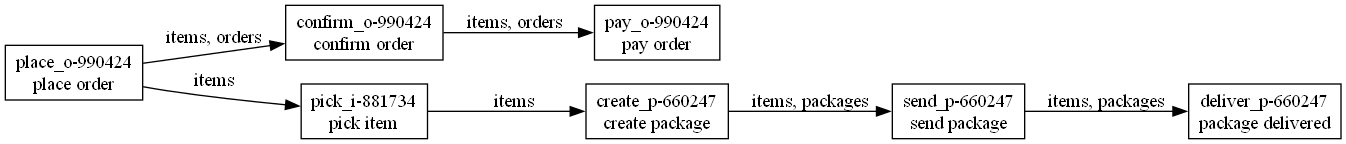

In [9]:
output_path = save_instance_graph(
    graph,
    GRAPHS_DIR
    / (
        "order_management_o_990424_"
        "discovered_instance_graph.png"
    ),
)

print(output_path.resolve())

display(
    Image(
        filename=str(output_path)
    )
)

## 10. Conclusioni

### Risultati dimostrati

- La lettura ingenua dei cammini della OCPN
  sovrageneralizza il comportamento degli item.
- Il filtering dell'OC-DFG seleziona relazioni
  fortemente direzionali e sufficientemente supportate.
- La topologia è stabile per un intervallo di soglie.
- Il grafo automatico contiene 7 nodi e 6 archi.
- Il grafo è un DAG transitivamente ridotto.
- Restano 8 coppie incomparabili.
- Il JSON manuale non è più necessario per costruire il
  grafo.

### Limiti

- Le soglie sono state validate su Order Management,
  non universalmente.
- Il risultato reale è stato verificato su una sola
  process execution controllata.
- Le relazioni sono inferite dall'OC-DFG filtrato, non
  lette direttamente dalla OCPN.
- Le relazioni tra attività con la stessa label sono
  escluse.
- Non è stato ancora realizzato un conformance checking
  object-centric.
- Non è stata dimostrata formalmente una fitness pari a
  1.
- Alignment e repairing restano fuori dall'ambito di questa analisi.

### Fonti

1. C. Diamantini, L. Genga, D. Potena e W. M. P.
   van der Aalst, *Building Instance Graphs for Highly
   Variable Processes*, 2016:
   https://www.sciencedirect.com/science/article/pii/S0957417416301877

2. W. M. P. van der Aalst e A. Berti,
   *Discovering Object-Centric Petri Nets*, 2020.

3. Documentazione ufficiale PM4Py:
   https://processintelligence.solutions/pm4py

4. Sorgente PM4Py relativo alla dependency:
   https://github.com/process-intelligence-solutions/pm4py/blob/release/pm4py/algo/filtering/dfg/dfg_filtering.py